#1: Training model recognition table

In [3]:
# ── Imports ───────────────────────────────────────────────
import torch
import random
import numpy as np
from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
import timm

import os, gc, time, shutil, subprocess, json
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

/Users/macbookpro14m1pro/Desktop/RagTable/python/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
BASE = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M")
ds1_img  = BASE / "table_segmentation_1/data/images"
ds1_mask = BASE / "table_segmentation_1/data/masks"
ds2_mask = BASE / "table_segmentation_2/data/masks"
ds3_mask = BASE / "table_segmentation_3/data/masks"

# Gom tất cả IDs có mask
all_mask_ids = set()
for mask_dir in [ds1_mask, ds2_mask, ds3_mask]:
    for f in mask_dir.glob("*_row.png"):
        all_mask_ids.add(f.stem.replace("_row", ""))

# IDs có image
all_img_ids = set(f.stem for f in ds1_img.glob("*.png"))

print(f"Total mask IDs: {len(all_mask_ids):,}")
print(f"Total image IDs: {len(all_img_ids):,}")
print(f"IDs có cả image lẫn mask: {len(all_mask_ids & all_img_ids):,}")
print(f"IDs có mask nhưng không có image: {len(all_mask_ids - all_img_ids):,}")
print(f"IDs có image nhưng không có mask: {len(all_img_ids - all_mask_ids):,}")

Total mask IDs: 30,000
Total image IDs: 30,000
IDs có cả image lẫn mask: 30,000
IDs có mask nhưng không có image: 0
IDs có image nhưng không có mask: 0


In [6]:
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# Đường dẫn cơ sở và các thư mục mask
BASE = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M")
mask_dirs = [BASE / "table_segmentation_1/data/masks",
             BASE / "table_segmentation_2/data/masks",
             BASE / "table_segmentation_3/data/masks"]

# Lấy tất cả ID từ các file mask (như bạn đã làm)
all_ids = set()
for mask_dir in mask_dirs:
    for f in mask_dir.glob("*_row.png"):
        all_ids.add(f.stem.replace("_row", ""))

total = len(all_ids)
has_header = 0
has_span = 0

# Duyệt qua từng ID, kiểm tra mask header và span
# Lưu ý: các file mask có thể nằm trong bất kỳ mask_dir nào, nên ta cần tìm đúng đường dẫn.
# Để tiện, ta sẽ tạo một dict ánh xạ từ ID đến thư mục chứa mask của nó (dựa vào một kênh bất kỳ, ví dụ _row.png)
id_to_dir = {}
for mask_dir in mask_dirs:
    for f in mask_dir.glob("*_row.png"):
        sample_id = f.stem.replace("_row", "")
        id_to_dir[sample_id] = mask_dir

# Bây giờ duyệt tất cả ID để thống kê
for sample_id in tqdm(sorted(all_ids), desc="Đang thống kê"):
    mask_dir = id_to_dir.get(sample_id)
    if mask_dir is None:
        print(f"Không tìm thấy thư mục cho ID {sample_id}, bỏ qua.")
        continue

    # Đọc mask col_header, row_header và span
    col_header_path = mask_dir / f"{sample_id}_col_header.png"
    row_header_path = mask_dir / f"{sample_id}_row_header.png"
    span_path = mask_dir / f"{sample_id}_span.png"

    try:
        col_header = np.array(Image.open(col_header_path))
        row_header = np.array(Image.open(row_header_path))
        span = np.array(Image.open(span_path))
    except FileNotFoundError as e:
        print(f"Thiếu file cho {sample_id}: {e}")
        continue

    # Kiểm tra header: nếu bất kỳ mask col_header hoặc row_header có pixel > 0
    if np.any(col_header > 0) or np.any(row_header > 0):
        has_header += 1

    # Kiểm tra span
    if np.any(span > 0):
        has_span += 1

print(f"\nTổng số mẫu: {total}")
print(f"Số mẫu có header (col_header hoặc row_header): {has_header} ({100*has_header/total:.1f}%)")
print(f"Số mẫu có ô gộp (span): {has_span} ({100*has_span/total:.1f}%)")

Đang thống kê:  34%|███▎      | 10104/30000 [00:05<00:11, 1747.57it/s]

Thiếu file cho sample_009723: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_3/data/masks/sample_009723_col_header.png'
Thiếu file cho sample_009725: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_3/data/masks/sample_009725_col_header.png'
Thiếu file cho sample_009726: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_3/data/masks/sample_009726_col_header.png'
Thiếu file cho sample_009727: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_2/data/masks/sample_009727_span.png'
Thiếu file cho sample_009728: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_2/data/masks/sample_009728_span.png'
Thiếu file cho sample_009729: [Errno 2] No such file or direct

Đang thống kê:  35%|███▍      | 10467/30000 [00:06<00:11, 1748.57it/s]

Thiếu file cho sample_010252: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_3/data/masks/sample_010252_col_header.png'


Đang thống kê:  36%|███▌      | 10821/30000 [00:06<00:12, 1564.03it/s]

...

Đang thống kê:  38%|███▊      | 11348/30000 [00:06<00:11, 1687.65it/s]

Thiếu file cho sample_011105: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_3/data/masks/sample_011105_row_header.png'


Đang thống kê:  40%|████      | 12106/30000 [00:07<00:10, 1714.47it/s]

Thiếu file cho sample_011750: [Errno 2] No such file or directory: '/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/table_segmentation_3/data/masks/sample_011750_row_header.png'


KeyboardInterrupt: 

In [ ]:
model = timm.create_model('efficientnet_b4', features_only=True)
for f in model.feature_info:
    print(f)

{'stage': 1, 'reduction': 2, 'module': 'blocks.0', 'num_chs': 24, 'index': 0}
{'stage': 2, 'reduction': 4, 'module': 'blocks.1', 'num_chs': 32, 'index': 1}
{'stage': 3, 'reduction': 8, 'module': 'blocks.2', 'num_chs': 56, 'index': 2}
{'stage': 5, 'reduction': 16, 'module': 'blocks.4', 'num_chs': 160, 'index': 3}
{'stage': 7, 'reduction': 32, 'module': 'blocks.6', 'num_chs': 448, 'index': 4}


In [7]:
# ── Config ────────────────────────────────────────────────
BATCH_SIZE = 8
IMG_SIZE = 384
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Đường dẫn ─────────────────────────────────────────────
BASE = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M")

IMG_DIR = BASE / "table_segmentation_1/data/images"

MASK_DIR_DILATED = BASE / "masks_dilated"

# Build lookup: sid → mask_dir
mask_dir_lookup = {}
for f in MASK_DIR_DILATED.glob("*_row.png"):
    sid = f.stem.replace("_row", "")
    mask_dir_lookup[sid] = MASK_DIR_DILATED

all_ids = sorted(mask_dir_lookup.keys())

print(f"Images:      {len(list(IMG_DIR.glob('*.png'))):,}")
print(f"Mask lookup: {len(mask_dir_lookup):,}")
print(f"Total IDs:   {len(all_ids):,}")
print(f"Device:      {device}")
# ── CELL 2: Dataset ───────────────────────────────────────
class TableDataset(Dataset):
    MASK_TYPES = ["row", "col", "col_header", "row_header", "span"]

    def __init__(self, sample_ids, augment=False):
        self.sample_ids = sample_ids
        self.augment    = augment

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sid = self.sample_ids[idx]
    
        img  = Image.open(IMG_DIR / f"{sid}.png").convert("RGB")
        mask_dir = mask_dir_lookup[sid]  # tự động chọn đúng thư mục
    
        masks = {}
        for mtype in self.MASK_TYPES:
            p = mask_dir / f"{sid}_{mtype}.png"
            masks[mtype] = Image.open(p).convert("L") if p.exists() \
                else Image.fromarray(np.zeros((IMG_SIZE, IMG_SIZE), np.uint8))
    
        if self.augment:
            img, masks = self._augment(img, masks)

        img = TF.resize(img, (IMG_SIZE, IMG_SIZE), 
                    interpolation=TF.InterpolationMode.BILINEAR)
        masks = {k: TF.resize(v, (IMG_SIZE, IMG_SIZE),
                    interpolation=TF.InterpolationMode.NEAREST)
             for k, v in masks.items()}
    
        img_t  = TF.to_tensor(img)
        mask_t = torch.cat([
            (TF.to_tensor(masks[m]) > 0.5).float()
            for m in self.MASK_TYPES
        ], dim=0)
        return {"image": img_t, "masks": mask_t, "sample_id": sid}

    def _augment(self, img, masks):
        all_imgs = [img] + list(masks.values())
    
        # Rotate nhiều hơn
        if random.random() > 0.5:
            angle = random.uniform(-3, 3)  
            all_imgs = [TF.rotate(i, angle) for i in all_imgs]
    
        # Horizontal flip (giữ)
        if random.random() > 0.5:
            all_imgs = [TF.hflip(i) for i in all_imgs]
    
        # Brightness/contrast (giữ)
        if random.random() > 0.5:
            all_imgs[0] = TF.adjust_brightness(all_imgs[0], random.uniform(0.7, 1.3))
            all_imgs[0] = TF.adjust_contrast(all_imgs[0], random.uniform(0.7, 1.3))
    
        img = all_imgs[0]
        for k, key in enumerate(masks.keys()):
            masks[key] = all_imgs[k+1]
        return img, masks

# Split train/val
random.seed(42)
random.shuffle(all_ids)
n_val     = int(len(all_ids) * 0.1)
train_ids = all_ids[:-n_val]
val_ids   = all_ids[-n_val:]

train_ds = TableDataset(train_ids, augment=True)
val_ds   = TableDataset(val_ids,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=0)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# Verify 1 batch
batch = next(iter(train_loader))
print(f"Image shape: {batch['image'].shape}")
print(f"Masks shape: {batch['masks'].shape}")
print(f"Masks unique: {batch['masks'].unique().tolist()}")

Images:      30,000
Mask lookup: 30,000
Total IDs:   30,000
Device:      cpu
Train: 27,000 | Val: 3,000
Train batches: 3375 | Val batches: 375
Image shape: torch.Size([8, 3, 384, 384])
Masks shape: torch.Size([8, 5, 384, 384])
Masks unique: [0.0, 1.0]


In [8]:
# ── CELL 3: EfficientNet-B4 + UNet Decoder ───────────────
class EfficientUNet(nn.Module):
    def __init__(self, out_ch=5, pretrained=True):
        super().__init__()

        # ── Encoder: EfficientNet-B4 ──────────────────
        self.encoder = timm.create_model(
            "efficientnet_b4",
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3, 4),
        )
        # EfficientNet-B4 channel sizes: 24, 32, 56, 160, 448
        enc_chs = self.encoder.feature_info.channels() 

        # ── Bottleneck ────────────────────────────────
        self.bottleneck = nn.Sequential(
            nn.Conv2d(enc_chs[4], 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )

        # ── Decoder blocks ────────────────────────────
        self.dec4 = self._dec_block(256 + enc_chs[3], 128)
        self.dec3 = self._dec_block(128 + enc_chs[2], 64)
        self.dec2 = self._dec_block(64  + enc_chs[1], 32)
        self.dec1 = self._dec_block(32  + enc_chs[0], 16)
        self.dec0 = self._dec_block(16, 16)  

        # ── Output ────────────────────────────────────
        self.out_conv = nn.Conv2d(16, out_ch, 1)

    def _dec_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        feats = self.encoder(x)  # [s0,s1,s2,s3,s4]
        s0, s1, s2, s3, s4 = feats

        # Bottleneck
        b = self.bottleneck(s4)

        # Decoder + skip connections
        x = F.interpolate(b,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec4(torch.cat([x, s3], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec3(torch.cat([x, s2], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec2(torch.cat([x, s1], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec1(torch.cat([x, s0], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec0(x)

        return self.out_conv(x)


# ── Verify ────────────────────────────────────────────────
model = EfficientUNet(out_ch=5, pretrained=False).to(device)
dummy = torch.randn(2, 3, 384, 384).to(device)
with torch.no_grad():
    out = model(dummy)

total = sum(p.numel() for p in model.parameters())
print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}")
print(f"Params: {total/1e6:.1f}M")
print(f"Output size match: {out.shape[-2:] == torch.Size([384, 384])}")

Input:  torch.Size([2, 3, 384, 384])
Output: torch.Size([2, 5, 384, 384])
Params: 19.2M
Output size match: True


In [9]:
# 1. Load Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_PATH = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/table-seg-checkpoints-v2/best_model_v2.pt")

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model_eval = EfficientUNet(out_ch=5, pretrained=False).to(device)
model_eval.load_state_dict(ckpt["model"])
model_eval.eval()

print(f"✅ Đã load Model từ epoch {ckpt['epoch']} (mIoU cũ: {ckpt['best_miou']:.4f})")

if 'history' in ckpt:
    val_miou_history = ckpt['history']['val_miou']
    print(f"📈 Số lượng Epoch đã lưu trong lịch sử: {len(val_miou_history)}")
    print(f"📊 5 Epoch cuối cùng: {val_miou_history[-5:]}")
    
    # Tìm giá trị lớn nhất trong lịch sử xem có khớp 0.7962 không
    max_in_history = max(val_miou_history)
    print(f"🏆 Giá trị cao nhất trong lịch sử: {max_in_history:.4f}")

# 2. Chuẩn bị DataLoader (Sử dụng val_ds đã có của bạn)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)

✅ Đã load Model từ epoch 92 (mIoU cũ: 0.7962)
📈 Số lượng Epoch đã lưu trong lịch sử: 92
📊 5 Epoch cuối cùng: [0.7914414340467895, 0.7906019581687095, 0.791963967882408, 0.7914080008316677, 0.7974435706013603]
🏆 Giá trị cao nhất trong lịch sử: 0.7974


In [10]:
# Hàm load model
def load_model(path, device):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model = EfficientUNet(out_ch=5, pretrained=False).to(device)
    model.load_state_dict(ckpt["model"])
    model = model.to(device)
    model.eval()
    return model, ckpt

# Đường dẫn
best_path = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/table-seg-checkpoints-v2/best_model.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model_best, ckpt_best = load_model(best_path, device)
print(f"✅ Load best model epoch {ckpt_best['epoch']} (mIoU: {ckpt_best['best_miou']:.4f})")

✅ Load best model epoch 97 (mIoU: 0.7946)


In [8]:
# Bộ ngưỡng lấy từ kết quả Ensemble
opt_thresholds = {
    "row": 0.65,
    "col": 0.50,
    "col_header": 0.45,
    "row_header": 0.30,
    "span": 0.65
}

In [ ]:
history_data = ckpt['history']

print("Kiểu dữ liệu của history:", type(history_data))

# 1. Nếu history là một danh sách các epoch (List of dicts)
if isinstance(history_data, list):
    for log in history_data:
        # Tìm đúng log của epoch 92
        if log.get('epoch', -1) == ckpt['epoch']: 
            print("\n🏆 CHI TIẾT TỪNG KÊNH CỦA EPOCH 92 🏆")
            for k, v in log.items():
                print(f"➤ {k:<15}: {v}")
            break

# 2. Nếu history là một từ điển chứa các mảng (Dict of lists)
elif isinstance(history_data, dict):
    print("\nCác thông số được lưu trong history:", history_data.keys())
    print("\n🏆 CHI TIẾT TỪNG KÊNH CỦA EPOCH 92 🏆")
    
    # Epoch 92 thường nằm ở vị trí index 91 (nếu lưu từ epoch 1)
    # hoặc index cuối cùng nếu lúc lưu best model bạn update history
    index_epoch = ckpt['epoch'] - 1 
    
    for key, values_list in history_data.items():
        if isinstance(values_list, list) and len(values_list) > index_epoch:
            val = values_list[index_epoch]
            # Format in cho đẹp nếu là số thập phân
            if isinstance(val, float):
                print(f"➤ {key:<15}: {val:.4f}")
            else:
                print(f"➤ {key:<15}: {val}")

Kiểu dữ liệu của history: <class 'dict'>

Các thông số được lưu trong history: dict_keys(['train_loss', 'val_loss', 'val_miou'])

🏆 CHI TIẾT TỪNG KÊNH CỦA EPOCH 92 🏆
➤ train_loss     : 0.2643
➤ val_loss       : 0.3186
➤ val_miou       : 0.7974


#2: Use model when training done

In [11]:
import numpy as np
import cv2
from PIL import Image
import torch
import torchvision.transforms.functional as TF
from dataclasses import dataclass
from typing import List
import re
from pathlib import Path
import matplotlib.pyplot as plt

In [12]:
@dataclass
class Cell:
    row_idx: int
    col_idx: int
    x: int; y: int; w: int; h: int
    is_span: bool = False
    col_span: int = 1
    text: str = ""

In [13]:
def masks_to_cell_boxes(row_mask, col_mask, span_mask,
                        col_header_mask=None, row_header_mask=None,
                        orig_w=384, orig_h=384, img_size=384) -> List[Cell]:
    # ── 1. Tách line → row_sep, col_sep (giữ nguyên) ───
    k_h = cv2.getStructuringElement(cv2.MORPH_RECT, (img_size // 4, 1))
    k_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, img_size // 4))
    k3  = np.ones((3, 3), np.uint8)

    h_lines = cv2.dilate(cv2.morphologyEx(row_mask * 255, cv2.MORPH_OPEN, k_h), k3, iterations=1)
    v_lines = cv2.dilate(cv2.morphologyEx(col_mask * 255, cv2.MORPH_OPEN, k_v), k3, iterations=1)

    def mask_to_positions(proj, min_gap=6):
        norm = proj / (proj.max() + 1e-6)
        is_line = norm > 0.03
        lines, in_line, start = [], False, 0
        for i, v in enumerate(is_line):
            if v and not in_line:
                in_line, start = True, i
            elif not v and in_line:
                in_line = False
                mid = (start + i) // 2
                if not lines or mid - lines[-1] >= min_gap:
                    lines.append(mid)
        return lines

    row_sep = [0] + mask_to_positions(h_lines.sum(axis=1).astype(float)) + [img_size]
    col_sep = [0] + mask_to_positions(v_lines.sum(axis=0).astype(float)) + [img_size]

    num_rows = len(row_sep) - 1
    num_cols = len(col_sep) - 1

    # ── 2. Cắt span_mask tại các grid separator ────────
    # Vẽ "tường ảo" tại đúng vị trí row_sep và col_sep, rồi xóa
    # các pixel span tại tường đó → tách các vùng tiếp xúc
    boundary = np.zeros_like(span_mask, dtype=np.uint8)
    wall = 2  # nửa độ rộng tường (pixel)
    for x in col_sep[1:-1]:
        boundary[:, max(0, x - wall):x + wall + 1] = 1
    for y in row_sep[1:-1]:
        boundary[max(0, y - wall):y + wall + 1, :] = 1

    span_binary = (span_mask > 0.5).astype(np.uint8)
    span_cut = span_binary * (1 - boundary)

    # ── 3. Connected components trên mask đã cắt ───────
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(span_cut, connectivity=8)

    # Lọc CC nhỏ
    valid_labels = set()
    for i in range(1, n_labels):
        if stats[i, cv2.CC_STAT_AREA] >= 30:
            valid_labels.add(i)

    print(f"  → {num_rows} rows, {num_cols} cols, "
          f"{len(valid_labels)} span region(s) sau khi cắt")

    # ── 4. Ánh xạ mỗi grid cell tới 1 component ────────
    cell_comp = np.zeros((num_rows, num_cols), dtype=np.int32)
    for r in range(num_rows):
        for c in range(num_cols):
            y1, y2 = row_sep[r], row_sep[r + 1]
            x1, x2 = col_sep[c], col_sep[c + 1]
            region = labels[y1:y2, x1:x2]
            if region.size == 0:
                continue
            # Lấy label trội (bỏ qua 0 = background)
            nonzero = region[region > 0]
            if nonzero.size == 0:
                continue
            uniq, cnts = np.unique(nonzero, return_counts=True)
            dom = int(uniq[cnts.argmax()])
            if dom in valid_labels and cnts.max() > 0.3 * region.size:
                cell_comp[r, c] = dom

    # ── 5. Build cells: merge các ô liên tiếp cùng comp_id ─
    sx, sy = orig_w / img_size, orig_h / img_size
    visited = np.zeros((num_rows, num_cols), dtype=bool)
    cells = []

    for r in range(num_rows):
        c = 0
        while c < num_cols:
            if visited[r, c]:
                c += 1
                continue

            comp = cell_comp[r, c]
            c_end = c
            if comp > 0:
                # Merge sang phải nếu CÙNG component
                while c_end + 1 < num_cols and cell_comp[r, c_end + 1] == comp:
                    c_end += 1
            # comp == 0 → cell bình thường, không merge

            for cc in range(c, c_end + 1):
                visited[r, cc] = True

            y1, y2 = row_sep[r], row_sep[r + 1]
            x1, x2 = col_sep[c], col_sep[c_end + 1]
            col_span = c_end - c + 1

            if (x2 - x1) >= 6 and (y2 - y1) >= 6:
                cells.append(Cell(
                    row_idx=r, col_idx=c,
                    x=int(x1 * sx), y=int(y1 * sy),
                    w=int((x2 - x1) * sx), h=int((y2 - y1) * sy),
                    is_span=(col_span > 1),
                    col_span=col_span,
                ))
            c = c_end + 1

    return cells, row_sep, col_sep

In [14]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,  
    text_detection_model_name=None,
    lang="en"
)

/Users/macbookpro14m1pro/Desktop/RagTable/python/.venv/lib/python3.10/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/macbookpro14m1pro/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/macbookpro14m1pro/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


In [38]:
import math
import re
import cv2
import numpy as np


# ═══════════════════════════════════════════════════════════════
# Pre-compiled regex
# ═══════════════════════════════════════════════════════════════
_RE_WHITESPACE    = re.compile(r"\s+")
_RE_BADCHARS      = re.compile(r"[^\w\s\.\,\-\(\)%±/=+:;|&'<>~]")
_RE_PERCENT_TAIL  = re.compile(r"%\d+")
_RE_PERCENT_96    = re.compile(r"(\d+\.\d)96\b")
_RE_PERCENT_VALUE = re.compile(r"(\d+\.\d+)%")
_RE_PM_SPACING    = re.compile(r"(\d)±\s*(\d)")


# ═══════════════════════════════════════════════════════════════
# Text cleaning 
# ═══════════════════════════════════════════════════════════════
def _normalize_percent_value(match):
    val = float(match.group(1))
    if val < 0.1:
        # Truncate (không round) đến 2 chữ số thập phân
        val = math.floor(val * 100) / 100
        return f"{val:.2f}%"
    return f"{val:.1f}%"


def clean_text(text, col_idx=None):
    if not text:
        return ""
    
    text = _RE_WHITESPACE.sub(" ", text.strip())
    text = _RE_BADCHARS.sub("", text)
    
    text = _RE_PERCENT_TAIL.sub("%", text)
    text = _RE_PERCENT_96.sub(r"\1%", text)
    text = _RE_PERCENT_VALUE.sub(_normalize_percent_value, text)
    text = _RE_PM_SPACING.sub(r"\1 ± \2", text)
    
    return text


# ═══════════════════════════════════════════════════════════════
# Image preprocessing
# ═══════════════════════════════════════════════════════════════
def resize_with_padding(img, target_height=64, target_width=256):
    """Resize giữ tỉ lệ, pad trắng để đạt kích thước mục tiêu."""
    h, w = img.shape[:2]
    ratio = min(target_width / w, target_height / h)
    new_w = int(w * ratio)
    new_h = int(h * ratio)
    
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    canvas = np.ones((target_height, target_width, 3), dtype=np.uint8) * 255
    
    x_offset = (target_width - new_w) // 2
    y_offset = (target_height - new_h) // 2
    canvas[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized
    return canvas


# ═══════════════════════════════════════════════════════════════
# Main OCR function 
# ═══════════════════════════════════════════════════════════════
def crop_and_ocr(image_pil, cells, ocr, upscale=3):
    img_np = np.array(image_pil.convert("RGB"))
    H, W = img_np.shape[:2]

    batch_imgs = []
    valid_cells = []

    for cell in cells:
        if cell.text:
            continue
        
        # if cell.w < 10 or cell.h < 10:
        #     cell.text = ""
        #     continue
        
        # aspect = max(cell.w, cell.h) / max(1, min(cell.w, cell.h))
        # if aspect > 30:
        #     cell.text = ""
        #     continue

        # Crop với padding
        pad = max(int(min(cell.w, cell.h) * 0.15), 3)
        x1 = max(0, cell.x - pad)
        y1 = max(0, cell.y - pad)
        x2 = min(W, cell.x + cell.w + pad)
        y2 = min(H, cell.y + cell.h + pad)

        crop = img_np[y1:y2, x1:x2]
        if crop.size == 0:
            cell.text = ""
            continue

        # Convert grayscale + adaptive scale
        gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)
        h_ratio = max(0.3, min(1.0, cell.h / 100.0))
        scale = 3.0 + (1 - h_ratio) * 2.0   # min=3.0, max=5.0

        new_w = int(gray.shape[1] * scale)
        new_h = int(gray.shape[0] * scale)
        gray = cv2.resize(gray, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
        
        # CLAHE enhancement
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        gray = clahe.apply(gray)

        # Convert + pad to fixed OCR input size
        img_input = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        img_input = resize_with_padding(img_input, target_height=64, target_width=256)

        batch_imgs.append(img_input)
        valid_cells.append(cell)

    # Batch OCR
    results = ocr.predict(batch_imgs)

    # Assign text với cleaning
    for cell, result in zip(valid_cells, results):
        texts = []
        if result and isinstance(result, dict) and "rec_texts" in result:
            texts.extend(result["rec_texts"])
        
        cell.text = clean_text(" ".join(t for t in texts if t))
    
    return cells

In [16]:
def cells_to_markdown(cells):
    if not cells:
        return ""
    max_row = max(c.row_idx for c in cells) + 1
    max_col = max(c.col_idx + c.col_span for c in cells)
    grid = [[None] * max_col for _ in range(max_row)]
    SPAN_MARKER = "__SPAN__"

    for cell in sorted(cells, key=lambda c: (c.row_idx, c.col_idx)):
        grid[cell.row_idx][cell.col_idx] = cell.text
        for off in range(1, cell.col_span):
            if cell.col_idx + off < max_col:
                grid[cell.row_idx][cell.col_idx + off] = SPAN_MARKER

    lines = []
    for r, row in enumerate(grid):
        cells_str = [("" if v in (None, SPAN_MARKER) else v) for v in row]
        lines.append("| " + " | ".join(cells_str) + " |")
        if r == 0:
            lines.append("| " + " | ".join(["---"] * max_col) + " |")
    return "\n".join(lines)

In [26]:
def detect_header_cells_via_ocr(image_pil, row_sep, col_sep, header_row_indices,
                                  ocr, orig_w, orig_h, img_size):
    img_np = np.array(image_pil.convert("RGB"))
    sx = orig_w / img_size
    sy = orig_h / img_size
    col_sep_orig = [int(c * sx) for c in col_sep]
    n_cols = len(col_sep_orig) - 1

    # Ngưỡng gap để mở rộng box (tỉ lệ theo orig_w để generalize qua ảnh kích thước khác)
    GAP_THRESHOLD = max(40, int(orig_w * 0.12))
    LEFT_BOUND = col_sep_orig[0]
    RIGHT_BOUND = col_sep_orig[-1]

    cells = []
    for r in header_row_indices:
        y1 = int(row_sep[r] * sy)
        y2 = int(row_sep[r + 1] * sy)
        if y2 - y1 < 8:
            continue

        strip = img_np[y1:y2, :]
        scaled = cv2.resize(strip, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)

        results = ocr.predict([scaled])
        if not results or not isinstance(results[0], dict):
            continue
        res = results[0]
        rec_texts = res.get("rec_texts", [])
        boxes = res.get("rec_polys") or res.get("rec_boxes") or res.get("dt_polys") or []

        # ── Step 1: collect text boxes với x-range ─────
        raw_boxes = []
        for text, box in zip(rec_texts, boxes):
            text = text.strip()
            if not text:
                continue
            box = np.asarray(box, dtype=float)
            if box.ndim == 1 and box.size == 4:
                xl, xr = box[0], box[2]
            else:
                xl, xr = box[:, 0].min(), box[:, 0].max()
            raw_boxes.append((xl / 3, xr / 3, text))
        raw_boxes.sort(key=lambda b: b[0])

        # ── Step 1.5: mở rộng x-range về phía neighbor nếu có gap lớn ──
        expanded_boxes = []
        for i, (xl, xr, text) in enumerate(raw_boxes):
            left_neighbor = raw_boxes[i - 1][1] if i > 0 else LEFT_BOUND
            if xl - left_neighbor > GAP_THRESHOLD:
                new_xl = (left_neighbor + xl) / 2
            else:
                new_xl = xl
            right_neighbor = raw_boxes[i + 1][0] if i + 1 < len(raw_boxes) else RIGHT_BOUND
            if right_neighbor - xr > GAP_THRESHOLD:
                new_xr = (xr + right_neighbor) / 2
            else:
                new_xr = xr
            expanded_boxes.append((new_xl, new_xr, text))

        # ── Step 2: map mỗi box (đã mở rộng) → (col_start, col_end) ─
        # Dùng overlap / cell_width thay vì overlap / box_width
        mapped = []
        for xl, xr, text in expanded_boxes:
            xc = (xl + xr) / 2
            col_start, col_end = None, None
            for c in range(n_cols):
                cl, cr = col_sep_orig[c], col_sep_orig[c + 1]
                cell_width = max(1, cr - cl)
                overlap = max(0, min(xr, cr) - max(xl, cl))
                if overlap / cell_width > 0.5 or (cl <= xc < cr):
                    if col_start is None:
                        col_start = c
                    col_end = c
            if col_start is None:
                continue
            mapped.append((col_start, col_end, text, xc))

        # ── Step 3: gộp boxes có col_range CHỒNG NHAU ──
        mapped.sort(key=lambda m: (m[0], m[3]))
        merged_boxes = []
        for cs, ce, txt, xc in mapped:
            if merged_boxes:
                pcs, pce, ptxt, pxc = merged_boxes[-1]
                if cs <= pce and ce >= pcs:
                    merged_boxes[-1] = (
                        min(pcs, cs), max(pce, ce),
                        ptxt + " " + txt, (pxc + xc) / 2
                    )
                    continue
            merged_boxes.append((cs, ce, txt, xc))

        # ── Step 4: tạo Cell, fill cell rỗng cho col trống ──
        covered = [False] * n_cols
        row_cells = []
        for cs, ce, text, _ in merged_boxes:
            for c in range(cs, ce + 1):
                covered[c] = True
            row_cells.append(Cell(
                row_idx=r, col_idx=cs,
                x=col_sep_orig[cs], y=y1,
                w=col_sep_orig[ce + 1] - col_sep_orig[cs], h=y2 - y1,
                is_span=(ce > cs), col_span=ce - cs + 1,
                text=text,
            ))

        c = 0
        while c < n_cols:
            if covered[c]:
                c += 1
                continue
            c_end = c
            while c_end + 1 < n_cols and not covered[c_end + 1]:
                c_end += 1
            for cc in range(c, c_end + 1):
                row_cells.append(Cell(
                    row_idx=r, col_idx=cc,
                    x=col_sep_orig[cc], y=y1,
                    w=col_sep_orig[cc + 1] - col_sep_orig[cc], h=y2 - y1,
                    is_span=False, col_span=1, text="",
                ))
            c = c_end + 1

        cells.extend(row_cells)

    return cells

In [18]:
def drop_empty_edge_columns(cells: List[Cell]) -> List[Cell]:
    """Loại bỏ cột rỗng hoàn toàn ở rìa trái/phải (phantom từ col_mask)."""
    if not cells:
        return cells
    max_col = max(c.col_idx + c.col_span for c in cells)

    # Cột nào có text không-rỗng?
    has_content = [False] * max_col
    for cell in cells:
        if cell.text.strip():
            for c in range(cell.col_idx, cell.col_idx + cell.col_span):
                if c < max_col:
                    has_content[c] = True

    # Tìm cột rỗng liên tục ở rìa trái và rìa phải
    left_drop = 0
    while left_drop < max_col and not has_content[left_drop]:
        left_drop += 1
    right_drop = max_col
    while right_drop > left_drop and not has_content[right_drop - 1]:
        right_drop -= 1

    if left_drop == 0 and right_drop == max_col:
        return cells  # không có phantom

    out = []
    for cell in cells:
        old_start = cell.col_idx
        old_end = cell.col_idx + cell.col_span - 1
        # Clip vào range [left_drop, right_drop - 1]
        new_start = max(old_start, left_drop)
        new_end = min(old_end, right_drop - 1)
        if new_start > new_end:
            continue  # cell hoàn toàn nằm trong vùng bị drop
        cell.col_idx = new_start - left_drop
        cell.col_span = new_end - new_start + 1
        cell.is_span = cell.col_span > 1
        out.append(cell)
    # print(f"  Dropped {left_drop} cột trái + {max_col - right_drop} cột phải")
    return out

def drop_empty_rows(cells: List[Cell]) -> List[Cell]:
    """Xoá row hoàn toàn rỗng và renumber row_idx."""
    from collections import defaultdict
    row_has_text = defaultdict(bool)
    for c in cells:
        if c.text.strip():
            row_has_text[c.row_idx] = True

    keep = [c for c in cells if row_has_text[c.row_idx]]
    if not keep:
        return []

    # Renumber row_idx liên tục từ 0
    old_rows = sorted({c.row_idx for c in keep})
    remap = {old: new for new, old in enumerate(old_rows)}
    for c in keep:
        c.row_idx = remap[c.row_idx]
    return keep


def drop_footer_rows(cells: List[Cell]) -> List[Cell]:
    """Xoá row chứa pattern footer (Author manuscript, PMC, doi, ...)."""
    from collections import defaultdict
    row_texts = defaultdict(list)
    for c in cells:
        row_texts[c.row_idx].append(c.text)

    FOOTER_RE = re.compile(
        r'author\s*manuscript|available\s*in\s*pmc|^\s*doi[:\s]|chem\s*phys',
        re.IGNORECASE
    )
    bad = {r for r, ts in row_texts.items() if FOOTER_RE.search(" ".join(ts))}
    return [c for c in cells if c.row_idx not in bad]

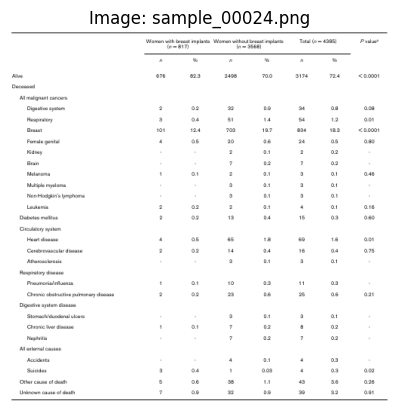

  → 32 rows, 8 cols, 9 span region(s) sau khi cắt

=== Markdown Output ===
|  | Women with breast implants Women without breaat implants (n - 817) (n - 3568) |  |  |  | Total (6 - 4385) |  | Pvaluea |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0 |  | 4 | 0 | % | n | 46 |  |
| Arve | 676 | 82.3 | 2498 | 70.0 | 3174 | 72.4 | <0.0001 |
| Deceased |  |  |  |  |  |  |  |
| All malignant cancers |  |  |  |  |  |  |  |
| Digestive system | 2 | 0.2 | 32 | 0.9 | 34 | 0.8 | 0.08 |
| Respiratory | 3 | 0.4 | 51 | 1.4 | 54 | 1.2 | 0.01 |
| Breast | 101 | 12.4 | 703 | 19.7 | 804 | 18.3 | <0.0001 |
| Female genital | 4 | 0.5 | 20 | 0.6 | 24 | 0.5 | 0.80 |
| Kdrey |  |  | 2 | 0.1 | 2 | 0.2 |  |
| Brain |  |  | 7 | 0.2 | 3 | 0.2 |  |
| Melanoma | 1 | 0.1 | 2 | 0.1 | 3 | 0.1 | 0.46 |
| Multiple mpeloma |  |  | 3 | 0.1 | 3 | 0.1 |  |
| Non-Hodgkin's lymphoma |  |  | 3 | 0.1 | 3 | 0.1 |  |
| Leukemria | 2 | 0.2 | 2 | 0.1 | 4 | 0.1 | 0.16 |
| Diabetes melitus | 2 | 0.2 | 13 | 0.4 | 15 | 0.3 | 0.60

In [39]:
def image_to_markdown_v3(image_path, model, device, img_size=384, upscale=3):
    orig_img = Image.open(image_path).convert("RGB")
    orig_w, orig_h = orig_img.size
    # print(f"Ảnh gốc: {orig_w}×{orig_h}px")

    draft = TF.resize(orig_img, (img_size, img_size),
                      interpolation=TF.InterpolationMode.BILINEAR)
    img_t = TF.to_tensor(draft).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        preds = torch.sigmoid(model(img_t)).squeeze(0).cpu().numpy()

    # Debug masks
    # mask_names = ['row', 'col', 'col_header', 'row_header', 'span']
    # fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    # for i, ax in enumerate(axes):
    #     ax.imshow(preds[i], cmap='hot', interpolation='nearest')
    #     ax.set_title(mask_names[i]); ax.axis('off')
    # plt.tight_layout(); plt.savefig('debug_masks.png'); plt.show()

    row_mask        = (preds[0] > 0.5).astype(np.uint8)
    col_mask        = (preds[1] > 0.5).astype(np.uint8)
    col_header_mask = (preds[2] > 0.5).astype(np.uint8)
    row_header_mask = (preds[3] > 0.5).astype(np.uint8)
    span_mask       = (preds[4] > 0.5).astype(np.uint8)

    # ── Cells từ mask + row_sep/col_sep ────────────────
    cells, row_sep, col_sep = masks_to_cell_boxes(
        row_mask, col_mask, span_mask,
        col_header_mask, row_header_mask,
        orig_w, orig_h, img_size
    )

    # ── Xác định header rows từ col_header_mask + row_sep THẬT ──
    num_rows_total = len(row_sep) - 1
    header_row_indices = []
    for r in range(num_rows_total):
        y1, y2 = row_sep[r], row_sep[r + 1]
        region = col_header_mask[y1:y2]
        if region.size > 0 and region.mean() > 0.5:
            header_row_indices.append(r)
    # print(f"Header rows: {header_row_indices}")

    # ── Override header cells bằng OCR-driven detection ────
    if header_row_indices:
        header_cells = detect_header_cells_via_ocr(
            orig_img, row_sep, col_sep, header_row_indices,
            ocr, orig_w, orig_h, img_size=img_size
        )
        cells = [c for c in cells if c.row_idx not in header_row_indices]
        cells.extend(header_cells)

    # ── OCR cho phần còn lại (header cells đã có text, sẽ skip) ──
    cells = crop_and_ocr(orig_img, cells, ocr, upscale=upscale)
    cells = drop_empty_edge_columns(cells) 
    cells = drop_footer_rows(cells)         
    cells = drop_empty_rows(cells)

    # Sort lại để cells_to_markdown đặt đúng thứ tự
    cells.sort(key=lambda c: (c.row_idx, c.col_idx))

    md = cells_to_markdown(cells)
    return md, cells

# ── Demo chạy thử ───────────────────────────────────────
TEST_IMG_DIR = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/images")
test_images = list(TEST_IMG_DIR.glob("*.png"))
if not test_images:
    test_images = list(TEST_IMG_DIR.glob("*.jpg"))

# random_img_path = random.choice(test_images)
random_img_path = TEST_IMG_DIR / "sample_00024.png"
img = Image.open(random_img_path)
plt.imshow(img)
plt.axis("off")
plt.title(f"Image: {random_img_path.name}")
plt.show()

md, cells = image_to_markdown_v3(random_img_path, model_best, device, img_size=384, upscale=3)
print("\n=== Markdown Output ===")
print(md)

In [30]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import time
from rapidfuzz import fuzz
import re

# 1. CÁC HÀM TÍNH ĐIỂM (Giữ nguyên chuẩn mực đánh giá)
def markdown_to_grid(md_str):
    if not md_str: return []
    lines = [l.strip() for l in md_str.split('\n') if l.strip() and '|' in l and '---' not in l]
    grid = [list(map(str.strip, l.strip('|').split('|'))) for l in lines]
    return grid

def super_clean(text):
    if not text: return ""
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

def calculate_cell_accuracy(md_pred, md_gt):
    grid_p = markdown_to_grid(md_pred)
    grid_g = markdown_to_grid(md_gt)
    
    if not grid_g: return 0.0
    if not grid_p: return 0.0 

    rows_g = len(grid_g)
    cols_g = len(grid_g[0])
    total_cells_gt = rows_g * cols_g
    
    match_count = 0
    
    for r in range(rows_g):
        for c in range(cols_g):
            try:
                p_raw = grid_p[r][c] if r < len(grid_p) and c < len(grid_p[0]) else ""
                g_raw = grid_g[r][c]
                
                p_text = super_clean(p_raw)
                g_text = super_clean(g_raw)
                
                if not p_text and not g_text:
                    match_count += 1
                elif p_text and g_text:
                    if p_text == g_text or fuzz.ratio(p_text, g_text) > 80:
                        match_count += 1
            except Exception:
                continue 
                
    return (match_count / total_cells_gt) * 100

In [ ]:
# 2. CẤU HÌNH ĐƯỜNG DẪN & CHUẨN BỊ DỮ LIỆU
GT_FOLDER = "/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/markdown_gt"
IMG_FOLDER = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/images")

# Lấy 200 mẫu (Nếu bạn muốn chạy HẾT toàn bộ thư mục, hãy xóa "[:200]")
SAMPLES = list(IMG_FOLDER.glob("*.png"))[:200]
if not SAMPLES:
    SAMPLES = list(IMG_FOLDER.glob("*.jpg"))[:200]

results = []

# 3. VÒNG LẶP ĐÁNH GIÁ CHÍNH
print(f"\n🚀 Bắt đầu chạy full đánh giá {len(SAMPLES)} samples trên Model U-Net...")
start_time = time.time()

for idx, sample_path in enumerate(tqdm(SAMPLES, desc="Đang xử lý")):
    filename = sample_path.stem
    gt_file = Path(GT_FOLDER) / f"{filename}.md"
    
    # Bỏ qua nếu không có file Ground Truth tương ứng
    if not gt_file.exists():
        continue
        
    try:
        t_start = time.time()
        unet_md, cells = image_to_markdown_v3(
            str(sample_path),
            model_best,            
            device,
            img_size=384,         
            upscale=3.0
        )
        t_end = time.time()
        elapsed = t_end - t_start
        
        # Đọc Ground Truth
        with open(gt_file, 'r', encoding='utf-8') as f:
            gt_md = f.read()
            
        # Tính điểm Accuracy
        acc = calculate_cell_accuracy(unet_md, gt_md)
        
        results.append({
            "index": idx,
            "filename": filename,
            "accuracy": acc,
            "time_sec": round(elapsed, 2),
            "num_cells": len(cells) if cells else 0
        })
    except Exception as e:
        print(f"⚠️ Lỗi tại file {filename}: {e}")

# 4. TỔNG HỢP VÀ XUẤT BÁO CÁO
df_results = pd.DataFrame(results)
avg_acc = df_results['accuracy'].mean()
total_time = time.time() - start_time

print("\n" + "="*45)
print(f"📊 KẾT QUẢ TỔNG HỢP: MODEL U-NET ({len(df_results)} SAMPLES)")
print("="*45)
print(f"➤ Độ chính xác trung bình (Cell-level) : {avg_acc:.2f}%")
print(f"➤ Số file đạt xuất sắc (> 90%)         : {len(df_results[df_results['accuracy'] >= 90])}")
print(f"➤ Số file bị lỗi cấu trúc (< 50%)      : {len(df_results[df_results['accuracy'] < 50])}")
print(f"➤ Tổng thời gian chạy                  : {total_time:.2f} giây")
print(f"➤ Tốc độ trung bình                    : {total_time/len(df_results):.2f} giây/ảnh")
print("="*45)

# Lưu file kết quả để vẽ biểu đồ chéo với file của Docling
df_results.to_csv("unet_pipeline_eval_results_v3.csv", index=False)
print("✅ Đã lưu kết quả chi tiết vào file: unet_pipeline_eval_results_v3.csv")


🚀 Bắt đầu chạy full đánh giá 200 samples trên Model U-Net...


Đang xử lý:   0%|          | 0/200 [00:00<?, ?it/s]

  → 13 rows, 5 cols, 6 span region(s) sau khi cắt


Đang xử lý:   0%|          | 1/200 [00:14<47:08, 14.21s/it]

  → 29 rows, 12 cols, 24 span region(s) sau khi cắt


...

Đang xử lý: 100%|█████████▉| 199/200 [41:44<00:10, 10.86s/it]

  → 18 rows, 5 cols, 0 span region(s) sau khi cắt


Đang xử lý: 100%|██████████| 200/200 [41:58<00:00, 12.59s/it]


📊 KẾT QUẢ TỔNG HỢP: MODEL U-NET (200 SAMPLES)
➤ Độ chính xác trung bình (Cell-level) : 80.48%
➤ Số file đạt xuất sắc (> 90%)         : 100
➤ Số file bị lỗi cấu trúc (< 50%)      : 27
➤ Tổng thời gian chạy                  : 2518.52 giây
➤ Tốc độ trung bình                    : 12.59 giây/ảnh
✅ Đã lưu kết quả chi tiết vào file: unet_pipeline_eval_results_v3.csv


: 